In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as pl
from soilice import loadModel

In [2]:
# Run all models using a makefile (only runs model if run script is modified):
!make

make: Nothing to be done for `all'.


In [3]:
run_1=loadModel('run_1.dill')
run_0=loadModel('../sensitivity/run_1.dill')

In [4]:
def getBalance(self):
    
    t=self.t
    nt,nz=self.thetaL.shape
    ml=self.thetaL*self.dz*self.const['rho_liq']
    mi=self.thetaI*self.dz*self.const['rho_ice']
    ms=np.zeros((nt,nz))+((1-self.pars['thetaS'])*self.dz*self.pars['rho_soil'])
    u=(ml*self.const['cp_liq']+mi*self.const['cp_ice']+ms*self.pars['cp_soil'])*self.T-mi*self.           const['lambda_f']
    ml=np.sum(ml,axis=1)
    mi=np.sum(mi,axis=1)
    u=np.sum(u,axis=1)
    du=u-u[0]
    m=ml+mi
    dm=m-m[0]
    qT=self.qT.cumsum()*self.const['rho_liq']
    qB=self.qB.cumsum()*self.const['rho_liq']
    jT=self.jT.cumsum()
    jB=self.jB.cumsum()
    jTA=qT*self.const['cp_liq']*self.TInf*self.opts['withadv']
    jBA=qB*self.const['cp_liq']*self.T[:,-1]*self.opts['withadv']
    uL=-mi*self.const['lambda_f']
    duL=uL-uL[0]
    return t,qT,qB,dm,jT,jB,du,jTA,jBA,duL

def printBalance(run):
    t,qT,qB,dm,jT,jB,du,jTA,jBA,duL,=getBalance(run)
    print(f'Total mass irrigated:        {run.qI[1:].sum()*1000*run.dt:.2f} kg/m2')
    print(f'Total mass infiltrated:      {qT[-1]:.2f} kg/m2')
    print(f'Total mass of runoff:        {run.qI[1:].sum()*1000*run.dt-qT[-1]:.2f} kg/m2')
    print(f'Total mass of drainage:      {qB[-1]:.2f} kg/m2')
    print(f'Change in mass:              {dm[-1]:.2f} kg/m2')
    print(f'Mass balance error:          {dm[-1]-(qT[-1]-qB[-1]):.4f} kg/m2')
    print(f'MB error as fraction of qT:  {(dm[-1]-(qT[-1]-qB[-1]))/qT[-1]:.4f} -')
    print('')
    print(f'Total top advection:         {jTA[-1]/1e3:.2f} kJ/m2')
    print(f'Total top conduction:        {(jT[-1]-jTA[-1])/1e3:.2f} kJ/m2')
    print(f'Total bottom advection:      {(jBA[-1])/1e3:.2f} kJ/m2')
    print(f'Total bottom conduction:     {(jB[-1]-jBA[-1])/1e3:.2f} kJ/m2')
    print(f'Change in internal energy:   {du[-1]/1e3:.1f} kJ/m2')
    print(f'Change in Latent heat:       {duL[-1]/1e3:.1f} kJ/m2')
    print(f'Change in Sensible heat:     {(du[-1]-duL[-1])/1e3:.1f} kJ/m2')
    print(f'Energy balance error:        {(du[-1]-(jT[-1]-jB[-1]))/1e3:.4f} kJ/m2')
    print(f'EB error as fraction of jT:  {(du[-1]-(jT[-1]-jB[-1]))/jT[-1]:.4f} -')


In [5]:
print('Original model run:')
printBalance(run_0)

print('\nSimplified MB model run:')
printBalance(run_1)

Original model run:
Total mass irrigated:        30.00 kg/m2
Total mass infiltrated:      30.00 kg/m2
Total mass of runoff:        0.00 kg/m2
Total mass of drainage:      1.17 kg/m2
Change in mass:              28.83 kg/m2
Mass balance error:          -0.0002 kg/m2
MB error as fraction of qT:  -0.0000 -

Total top advection:         0.00 kJ/m2
Total top conduction:        2154.46 kJ/m2
Total bottom advection:      -4.90 kJ/m2
Total bottom conduction:     812.16 kJ/m2
Change in internal energy:   1346.8 kJ/m2
Change in Latent heat:       -170.1 kJ/m2
Change in Sensible heat:     1517.0 kJ/m2
Energy balance error:        -0.3707 kJ/m2
EB error as fraction of jT:  -0.0002 -

Simplified MB model run:
Total mass irrigated:        30.00 kg/m2
Total mass infiltrated:      30.00 kg/m2
Total mass of runoff:        0.00 kg/m2
Total mass of drainage:      1.17 kg/m2
Change in mass:              28.83 kg/m2
Mass balance error:          -0.0002 kg/m2
MB error as fraction of qT:  -0.0000 -

Total to

In [6]:
print(-0.3719/2139.40*100)
print(-12.1562/2141.06*100)

-0.01738337851734131
-0.5677654993321066


In [7]:
def RMSE(x,y):
    return np.sqrt(np.mean((x-y)**2))

print(RMSE(np.squeeze(run_1.thetaT),np.squeeze(run_0.thetaT)))
print(RMSE(np.squeeze(run_1.thetaL),np.squeeze(run_0.thetaL)))
print(RMSE(np.squeeze(run_1.thetaI),np.squeeze(run_0.thetaI)))
print(RMSE(np.squeeze(run_1.T),np.squeeze(run_0.T)))

1.424920296027146e-05
2.7774936685976875e-05
3.510609101932854e-05
0.0002528851406892545


Total mass irrigated:        30.00 kg/m2
Total mass infiltrated:      30.00 kg/m2
Total mass of runoff:        0.00 kg/m2
Total mass of drainage:      1.18 kg/m2
Change in mass:              28.82 kg/m2
Mass balance error:          -0.0002 kg/m2
MB error as fraction of qT:  -0.0000 -

Total top advection:         0.00 kJ/m2
Total top conduction:        2139.40 kJ/m2
Total bottom advection:      -4.93 kJ/m2
Total bottom conduction:     816.62 kJ/m2
Change in internal energy:   1327.3 kJ/m2
Change in Latent heat:       -140.4 kJ/m2
Change in Sensible heat:     1467.7 kJ/m2
Energy balance error:        -0.3719 kJ/m2
EB error as fraction of jT:  -0.0002 -


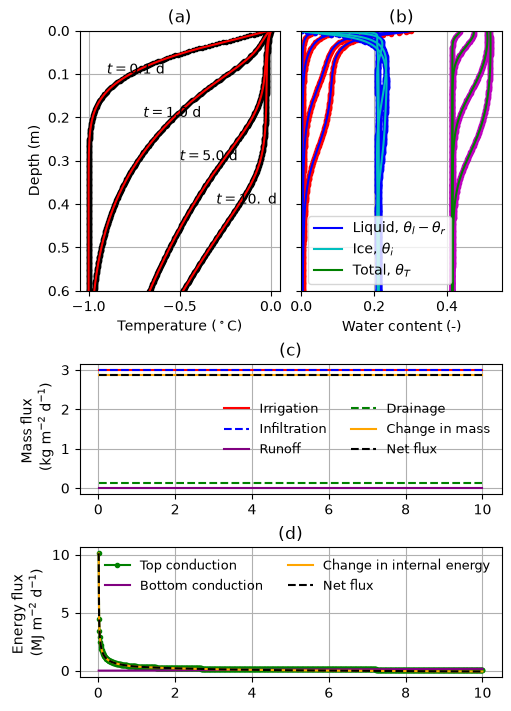

In [12]:
#########################
# Second results figure
#########################

def doublePlot(run,old,fn,ncol=3):

    times=[0.1,1,5,10]
    ti=[int(i/run.dt) for i in times]
    ti2=[int(i/old.dt) for i in times]
    lowerlim=0.6
    fig = pl.figure(figsize=(5,7), constrained_layout=True)
    
    gs = fig.add_gridspec(
        nrows=3,
        ncols=2,
        height_ratios=[2, 1, 1]
    )
    
    # Two subplots across the upper half
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    
    # Full-width subplots in the lower quarters
    ax3 = fig.add_subplot(gs[1, :])
    ax4 = fig.add_subplot(gs[2, :])
    
    # Example labels
    ax1.set_title("(a)")
    ax2.set_title("(b)")
    ax3.set_title("(c)")
    ax4.set_title("(d)")
    
    ########################################################################
    
    ax1.plot(run.T[ti,:].T,run.z,'k.')
    ax1.plot(old.T[ti2,:].T,old.z,'r')
    ax1.set_ylim(lowerlim,0)
    # ax1.set_xlim(-0.5,0)
    ax1.grid()
    ax1.set_xlabel(r'Temperature ($^\circ$C)')
    ax1.set_ylabel('Depth (m)')
    ax1.text(-0.9,0.1,r'$t=0.1$ d')
    ax1.text(-0.7,0.2,r'$t=1.0$ d')
    ax1.text(-0.5,0.3,r'$t=5.0$ d')
    ax1.text(-0.3,0.4,r'$t=10.$ d')
    
    
    
    ax2.plot(run.thetaL[ti,:].T-run.pars['thetaR'],run.z,'r.')
    ax2.plot(old.thetaL[ti2,:].T-old.pars['thetaR'],old.z,'b')
    ax2.plot(run.thetaI[ti,:].T,run.z,'b.')
    ax2.plot(old.thetaI[ti2,:].T,old.z,'c')
    ax2.plot(run.thetaT[ti,:].T,run.z,'m.')
    ax2.plot(old.thetaT[ti2,:].T,old.z,'g')
    ax2.plot([],[],'b',label=r'Liquid, $\theta_l-\theta_r$')
    ax2.plot([],[],'c',label=r'Ice, $\theta_i$')
    ax2.plot([],[],'g',label=r'Total, $\theta_T$')
    
    ax2.legend(loc=3)
    ax2.set_ylim(lowerlim,0)
    ax2.set_xlim(0,0.55)
    ax2.grid()
    ax2.set_xlabel('Water content (-)')
    ax2.set_yticklabels([])
    
    
    t,qT,qB,dm,jT,jB,du,jTA,jBA,duL=getBalance(run)
    # ax3.plot(t,np.cumsum(run.qI*run.dt)*1000,color='purple',label='Cum. irrigation')
    # ax3.plot(t,np.cumsum(run.qI*run.dt*1000)-qT,color='blue',label='Cum. runoff')
    # ax3.plot(t,qB,color='blue',label='Cum. drainage')
    # ax3.plot(t,qT-qB,'.',color='orange',label='Net water balance')
    # ax3.plot(t,dm,'-k',label='Cum. change in mass')
    # ax3.grid(); ax3.legend(ncol=2)
    # ax3.set_ylabel(r'Mass flux\n (kg m$^{-2}$)')

    ax3.plot(t[1:],run.qI[1:]*1000,'r',label='Irrigation')
    ax3.plot(t[1:],np.diff(qT)/run.dt,'--b',label='Infiltration')
    ax3.plot(t[1:],run.qI[1:]*1000-np.diff(qT)/run.dt,color='purple',label='Runoff')
    ax3.plot(t[1:],np.diff(qB)/run.dt,'--',color='green',label='Drainage')
    
    ax3.plot(t[1:],np.diff(dm)/run.dt,'-',color='orange',label='Change in mass')
    ax3.plot(t[1:],np.diff(qT-qB)/run.dt,'--k',label='Net flux')
    ax3.grid(); ax3.legend(ncols=ncol,fontsize=9,frameon=False)
    ax3.set_ylabel('Mass flux \n (kg m$^{-2}$ d$^{-1}$)')


    ax4.plot(t[1:],np.diff(jT-jTA)/1e6/run.dt,'.-',color='green',label='Top conduction')
    # ax4.plot(t[1:],np.diff(jTA)/1e6/run.dt,'--',color='blue',label='Top advection')
    ax4.plot(t[1:],np.diff(jB-jBA)/1e6/run.dt,'-',color='purple',label='Bottom conduction')
    # ax4.plot(t[1:],np.diff(jBA)/1e6/run.dt,'--',color='green',label='Bottom advection')

    
    ax4.plot(t[1:],np.diff(du)/run.dt/1e6,'-',color='orange',label='Change in internal energy')
    ax4.plot(t[1:],np.diff(jT-jB)/1e6/run.dt,'--k',label='Net flux')
    ax4.grid(); ax4.legend(ncols=2,fontsize=9,frameon=False)
    ax4.set_ylabel('Energy flux \n(MJ m$^{-2}$ d$^{-1}$)')
    
    # pl.savefig(fn,dpi=300)

doublePlot(run_1,run_0,'figures/run_2.png',ncol=2)
printBalance(run_0)